# 🏠 Smart Home Energy Analytics
## Construcción del Dataset Maestro

### Hackathon Ciencia de Datos – CD3

---

## Objetivo

Construir un Dataset Maestro consolidado a partir del conjunto de datos de consumo energético de viviendas inteligentes.

El resultado será un dataset limpio, consistente y preparado para posteriores procesos de Machine Learning, garantizando:

- Calidad de los datos.
- Reproducibilidad.
- Integridad.
- Documentación técnica.
- Exportación automática.

---

## Flujo del Proyecto
Raw Dataset
        │
        ▼
Carga de Datos
        │
        ▼
Validación Inicial
        │
        ▼
Limpieza
        │
        ▼
Análisis Exploratorio
        │
        ▼
Ingeniería de Variables
        │
        ▼
Construcción Dataset Maestro
        │
        ▼
Reporte de Calidad
        │
        ▼
Train / Test
        │
        ▼
Exportación

In [11]:

# ==========================================================
# CONFIGURACIÓN GENERAL DEL PROYECTO 2
# ==========================================================

from pathlib import Path

PROJECT_NAME = "Smart Home Energy Analytics"

PROJECT_VERSION = "1.0"

AUTHOR = "Equipo CD3"

RANDOM_STATE = 42

TEST_SIZE = 0.20

ROOT = Path(".")

DATASET = ROOT / "smart_home_energy_consumption_large.csv"

OUTPUT = ROOT / "output"

OUTPUT.mkdir(exist_ok=True)

print(f"Proyecto : {PROJECT_NAME}")
print(f"Versión  : {PROJECT_VERSION}")
print(f"Salida   : {OUTPUT}")

Proyecto : Smart Home Energy Analytics
Versión  : 1.0
Salida   : output


In [12]:
# ==========================================================
# CONFIGURACIÓN ESPECÍFICA DE INGENIERÍA DE CARACTERÍSTICAS 3
# ==========================================================

PEAK_START = 19  # Inicio de la hora pico (6 PM)
PEAK_END = 22    # Fin de la hora pico (10 PM)
PEAK_THRESHOLD = 0.5 # Umbral para considerar uso de horario pico

In [13]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS 4
# ==========================================================

import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [14]:
# ==========================================================
# CONFIGURACIÓN DEL LOGGING 5
# ==========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

logger.info("Inicio del Proyecto")

In [15]:
def print_title(title: str):
    """Imprime un título con formato para mejorar la lectura del notebook."""
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

In [16]:
def dataset_shape(df):
    """Retorna el número de filas y columnas del DataFrame."""
    return {
        "filas": df.shape[0],
        "columnas": df.shape[1]
    }

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# ==========================================================
# CARGA DEL DATASET 8
# ==========================================================

print_title("CARGA DEL DATASET")

try:
    df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/hackathon_team_30/smart_home_energy_consumption_large.csv")

    logger.info("Dataset cargado correctamente.")

    print(f"Filas    : {df.shape[0]:,}")
    print(f"Columnas : {df.shape[1]}")

except FileNotFoundError:

    logger.error("No fue posible encontrar el dataset.")

    raise


CARGA DEL DATASET
Filas    : 100,000
Columnas : 8


In [33]:
# ==========================================================
# VISTA GENERAL 10
# ==========================================================

print_title("PRIMEROS REGISTROS")

display(df.head())

print_title("ÚLTIMOS REGISTROS")

display(df.tail())


PRIMEROS REGISTROS


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5



ÚLTIMOS REGISTROS


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
99995,124,Microwave,0.42,09:56,2023-09-28,20.5,Summer,1
99996,184,Computer,0.71,12:48,2023-05-27,-5.4,Spring,2
99997,101,Dishwasher,0.25,05:45,2023-02-18,35.6,Winter,3
99998,423,Air Conditioning,2.69,12:39,2023-04-20,3.7,Spring,1
99999,429,Fridge,0.37,18:46,2023-02-27,36.0,Winter,5


In [34]:
print_title("INFORMACIÓN GENERAL")

df.info()


INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [23]:
print_title("ESTADÍSTICAS DESCRIPTIVAS")

display(df.describe(include="all").T)


ESTADÍSTICAS DESCRIPTIVAS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Home ID,100000.0,NaN,NaN,NaN,250.37498,144.435367,1.0,125.0,250.0,375.0,500.0
Appliance Type,100000,10,Lights,10201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Energy Consumption (kWh),100000.0,NaN,NaN,NaN,1.499952,1.181176,0.1,0.59,1.23,1.87,5.0
Time,100000,1440,02:44,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,100000,366,2023-10-08,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outdoor Temperature (°C),100000.0,NaN,NaN,NaN,14.950135,14.438755,-10.0,2.4,14.9,27.4,40.0
Season,100000,4,Spring,25112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Household Size,100000.0,NaN,NaN,NaN,3.00177,1.417077,1.0,2.0,3.0,4.0,5.0


# 5. Validaciones iniciales del Dataset

Antes de iniciar la construcción del Dataset Maestro se realizan una serie de validaciones
para verificar la integridad del dataset original.

Estas validaciones permiten detectar problemas de calidad antes del proceso de agregación.

Se verificará:

- Existencia del identificador del hogar (Home ID).
- Valores nulos.
- Consumos negativos.
- Consistencia de la variable Household Size.
- Valores nulos en Appliance Type.

In [35]:
# ==========================================================
# VALIDACIONES INICIALES
# ==========================================================

print("="*70)
print("VALIDACIONES INICIALES")
print("="*70)

# ----------------------------------------------------------
# 1. Verificar existencia de Home ID
# ----------------------------------------------------------

assert "Home ID" in df.columns, \
    "La columna 'Home ID' no existe."

print("✓ Home ID encontrado")


# ----------------------------------------------------------
# 2. Home ID sin valores nulos
# ----------------------------------------------------------

assert df["Home ID"].isnull().sum() == 0, \
    "Existen Home ID nulos."

print("✓ Home ID sin valores nulos")


# ----------------------------------------------------------
# 3. Consistencia de Household Size
# ----------------------------------------------------------

household_validation = (
    df
    .groupby("Home ID")["Household Size"]
    .nunique()
)

problematic = household_validation[household_validation > 1]

print(f"\nHogares con múltiples valores de Household Size: {len(problematic)}")

if len(problematic) > 0:
    print("Se utilizará la moda para consolidar la variable cantidad_personas.")
else:
    print("Todos los hogares presentan un único valor de Household Size.")


# ----------------------------------------------------------
# 4. Consumos negativos
# ----------------------------------------------------------

assert (
    df["Energy Consumption (kWh)"] >= 0
).all(), "Se encontraron consumos negativos."

print("✓ Consumos válidos")


# ----------------------------------------------------------
# 5. Appliance Type
# ----------------------------------------------------------

assert (
    df["Appliance Type"]
    .isnull()
    .sum()
    == 0
), "Existen Appliance Type nulos."

print("✓ Appliance Type válido")

print("\nTodas las validaciones iniciales fueron superadas.")

VALIDACIONES INICIALES
✓ Home ID encontrado
✓ Home ID sin valores nulos

Hogares con múltiples valores de Household Size: 500
Se utilizará la moda para consolidar la variable cantidad_personas.
✓ Consumos válidos
✓ Appliance Type válido

Todas las validaciones iniciales fueron superadas.


# 6. Funciones auxiliares

Para facilitar el mantenimiento del notebook, toda la lógica del proceso se implementa
mediante funciones reutilizables.

Las funciones construyen el pipeline completo de generación del Dataset Maestro.

In [36]:
# ==========================================================
# FUNCIONES AUXILIARES
# ==========================================================

def mode_value(series):
    """
    Retorna la moda de una serie.

    Si existen varias modas,
    se selecciona la primera.

    Parameters
    ----------
    series : pandas.Series

    Returns
    -------
    object
    """

    modes = series.mode()

    if not modes.empty:
        return modes.iloc[0]

    return series.iloc[0]

# 7. Ingeniería de características temporales

El dataset original contiene la variable **Time**, a partir de la cual se generan
variables temporales que describen el comportamiento del consumo energético.

En esta etapa se identifica si un registro corresponde al horario pico de consumo.

In [37]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

def create_temporal_features(df):
    """
    Genera variables temporales necesarias para el Dataset Maestro.

    Parameters
    ----------
    df : pandas.DataFrame

    Returns
    -------
    pandas.DataFrame
    """

    data = df.copy()

    # Conversión de fecha
    data["Time"] = pd.to_datetime(data["Time"])

    # Hora del día
    data["hour"] = data["Time"].dt.hour

    # Horario pico
    data["is_peak_hour"] = (
        (data["hour"] >= PEAK_START) &
        (data["hour"] < PEAK_END)
    )

    return data


# 8. Construcción del Dataset Maestro

En esta etapa se consolida toda la información de cada hogar.

Cada registro del Dataset Maestro representa un único hogar (Home ID).

In [102]:
# ==========================================================
# AGREGACIÓN POR HOGAR
# ==========================================================

def aggregate_home_dataset(df):
    """
    Construye el Dataset Maestro agregando toda la información
    por Home ID.

    Parameters
    ----------
    df : pandas.DataFrame

    Returns
    -------
    pandas.DataFrame
    """

    aggregation = {

        # Estadísticas del consumo energético
        "Energy Consumption (kWh)": [
            "sum",
            "mean",
            "max",
            "min",
            "std",
            "count"
        ],

        # Número de personas
        "Household Size": mode_value,

        # Cantidad de tipos de equipos
        "Appliance Type": "nunique",

        # Temperatura exterior
        "Outdoor Temperature (°C)": [
            "mean",
            "max",
            "min"
        ],

        # Proporción de registros en horario pico
        "is_peak_hour": "mean"

    }

    homes = (
        df
        .groupby("Home ID")
        .agg(aggregation)
        .reset_index()
    )

    # Eliminar MultiIndex
    homes.columns = [

    "Home ID",

    "consumo_total_kwh",
    "consumo_promedio_kwh",
    "consumo_maximo_kwh",
    "consumo_minimo_kwh",
    "desviacion_consumo_kwh",
    "numero_mediciones",

    "cantidad_personas",

    "cantidad_equipos",

    "temperatura_promedio",
    "temperatura_maxima",
    "temperatura_minima",

    "porcentaje_horario_pico"

]

    # Reemplazar posibles NaN de la desviación estándar
    homes["desviacion_consumo_kwh"] = (
        homes["desviacion_consumo_kwh"]
        .fillna(0)
    )

    # Coeficiente de variación
    homes["coeficiente_variacion"] = (
        homes["desviacion_consumo_kwh"] /
        homes["consumo_promedio_kwh"]
    ).fillna(0)

   # Variable requerida por la API
    homes["uso_horario_pico"] = (
    homes["porcentaje_horario_pico"] >= PEAK_THRESHOLD
    )

    return homes

# 9. Validación del Dataset Maestro

Después de la agregación se verifica que el Dataset Maestro
cumpla los criterios mínimos de calidad antes de continuar
con el pipeline.

In [103]:
# ==========================================================
# VALIDACIÓN DEL DATASET MAESTRO 14
# ==========================================================

def validate_home_dataset(homes):
    """
    Valida la estructura y consistencia del Dataset Maestro.

    Parameters
    ----------
    homes : pandas.DataFrame
    """

    # Home ID único
    assert homes["Home ID"].is_unique, \
        "Existen Home ID duplicados."

    # Sin valores nulos
    assert homes.isnull().sum().sum() == 0, \
        "Existen valores nulos."

    # Consumo total
    assert (
        homes["consumo_total_kwh"] >= 0
    ).all(), "Consumo total inválido."

    # Consumo promedio
    assert (
        homes["consumo_promedio_kwh"] >= 0
    ).all(), "Consumo promedio inválido."

    # Personas
    assert (
        homes["cantidad_personas"] > 0
    ).all(), "Cantidad de personas inválida."


    # Número de registros
    assert (
        homes["numero_mediciones"] > 0
    ).all(), "Cantidad de registros inválida."

    print("✓ Dataset Maestro validado correctamente.")

# 10. Construcción automática del Dataset Maestro

Esta función integra todas las etapas anteriores
en un único flujo de procesamiento.

In [104]:

# ==========================================================
# PIPELINE COMPLETO 16
# ==========================================================

def build_home_dataset(df):
    """
    Ejecuta todo el pipeline de construcción
    del Dataset Maestro.
    """

    data = create_temporal_features(df)

    homes = aggregate_home_dataset(data)

    validate_home_dataset(homes)

    return homes

In [105]:
# ==========================================================
# CONSTRUCCIÓN DEL DATASET MAESTRO 17
# ==========================================================

homes = build_home_dataset(df)

print("Dataset Maestro construido correctamente.")

homes.head()

✓ Dataset Maestro validado correctamente.
Dataset Maestro construido correctamente.


,Home ID,consumo_total_kwh,consumo_promedio_kwh,consumo_maximo_kwh,consumo_minimo_kwh,desviacion_consumo_kwh,numero_mediciones,cantidad_personas,cantidad_equipos,temperatura_promedio,temperatura_maxima,temperatura_minima,porcentaje_horario_pico,coeficiente_variacion,uso_horario_pico
0,1,324.76,1.539147,4.88,0.10,1.171695,211,3,10,13.632701,39.8,-9.9,0.090047,0.761263,False
1,2,311.52,1.490526,4.93,0.15,1.096428,209,3,10,15.357895,39.6,-9.7,0.119617,0.735598,False
2,3,332.06,1.537315,4.98,0.14,1.229080,216,5,10,13.097685,39.9,-9.7,0.189815,0.799498,False
3,4,262.56,1.458667,4.92,0.11,1.153659,180,5,10,13.543333,38.7,-9.5,0.100000,0.790900,False
4,5,297.07,1.435121,4.91,0.12,1.175420,207,1,10,13.954106,39.9,-9.9,0.101449,0.819039,False


# 11. Auditoría del Dataset Maestro

Una vez construido el Dataset Maestro, se realiza una auditoría para verificar
su estructura, tipos de datos, valores nulos, duplicados y uso de memoria.

Esta auditoría permite confirmar que el dataset se encuentra listo para la etapa
de modelado.

In [86]:
# ==========================================================
# AUDITORÍA DEL DATASET 19
# ==========================================================

def audit_dataset(df):
    """
    Realiza una auditoría general del Dataset Maestro.

    Parameters
    ----------
    df : pandas.DataFrame
    """

    print("=" * 70)
    print("AUDITORÍA DEL DATASET MAESTRO")
    print("=" * 70)

    print(f"\nNúmero de registros : {df.shape[0]}")
    print(f"Número de variables : {df.shape[1]}")

    print("\nValores nulos")
    print(df.isnull().sum())

    print("\nDuplicados")
    print(df.duplicated().sum())

    print("\nTipos de datos")
    print(df.dtypes)

    memoria = df.memory_usage(deep=True).sum() / 1024**2

    print(f"\nUso de memoria: {memoria:.2f} MB")

In [87]:
audit_dataset(homes)

AUDITORÍA DEL DATASET MAESTRO

Número de registros : 500
Número de variables : 13

Valores nulos
Home ID                    0
consumo_total_kwh          0
consumo_promedio_kwh       0
consumo_maximo_kwh         0
consumo_minimo_kwh         0
desviacion_consumo_kwh     0
numero_mediciones          0
cantidad_personas          0
temperatura_promedio       0
temperatura_maxima         0
temperatura_minima         0
porcentaje_horario_pico    0
coeficiente_variacion      0
dtype: int64

Duplicados
0

Tipos de datos
Home ID                      int64
consumo_total_kwh          float64
consumo_promedio_kwh       float64
consumo_maximo_kwh         float64
consumo_minimo_kwh         float64
desviacion_consumo_kwh     float64
numero_mediciones            int64
cantidad_personas            int64
temperatura_promedio       float64
temperatura_maxima         float64
temperatura_minima         float64
porcentaje_horario_pico    float64
coeficiente_variacion      float64
dtype: object

Uso de memori

# 12. Estadísticas descriptivas

Se presentan las estadísticas generales del Dataset Maestro con el fin de
verificar la distribución de las variables numéricas.

In [88]:
homes.describe(include="all")

,Home ID,consumo_total_kwh,consumo_promedio_kwh,consumo_maximo_kwh,consumo_minimo_kwh,desviacion_consumo_kwh,numero_mediciones,cantidad_personas,temperatura_promedio,temperatura_maxima,temperatura_minima,porcentaje_horario_pico,coeficiente_variacion
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,299.990320,1.499564,4.925220,0.118060,1.179392,200.000000,2.990000,14.944393,39.746400,-9.749200,0.124022,0.787056
std,144.481833,27.189485,0.079868,0.078189,0.017569,0.067764,13.885157,1.459507,1.002943,0.263564,0.259218,0.022600,0.034699
min,1.000000,223.640000,1.277943,4.330000,0.100000,0.972497,157.000000,1.000000,11.441624,38.500000,-10.000000,0.063158,0.689019
25%,125.750000,282.275000,1.444485,4.897500,0.110000,1.138445,191.000000,2.000000,14.246001,39.675000,-9.900000,0.108108,0.763923
50%,250.500000,300.215000,1.493178,4.950000,0.110000,1.177938,200.000000,3.000000,14.941172,39.800000,-9.800000,0.122684,0.787148
75%,375.250000,316.500000,1.555357,4.980000,0.130000,1.226596,209.000000,4.000000,15.646697,39.900000,-9.700000,0.139237,0.810512
max,500.000000,391.500000,1.754920,5.000000,0.210000,1.360822,245.000000,5.000000,17.954144,40.000000,-8.500000,0.189815,0.896429


# 13. Validación de conservación de energía

Durante el proceso de agregación, el consumo energético total no debe alterarse.

Se compara la suma del consumo del dataset original con la suma obtenida en el
Dataset Maestro.

In [89]:
# ==========================================================
# VALIDACIÓN DE CONSERVACIÓN DE ENERGÍA 24
# ==========================================================

def validate_energy(original_df, aggregated_df):
    """
    Verifica que la energía total del dataset original
    sea igual a la energía total del Dataset Maestro.
    """

    energia_original = original_df["Energy Consumption (kWh)"].sum()

    energia_agregada = aggregated_df["consumo_total_kwh"].sum()

    diferencia = abs(
        energia_original - energia_agregada
    )

    print("=" * 70)
    print("VALIDACIÓN DE CONSERVACIÓN DE ENERGÍA")
    print("=" * 70)

    print(f"Energía original : {energia_original:.4f}")
    print(f"Energía agregada : {energia_agregada:.4f}")
    print(f"Diferencia       : {diferencia:.10f}")

    assert np.isclose(
        energia_original,
        energia_agregada,
        atol=1e-8
    ), "La energía no se conservó."

    print("\n✓ Conservación de energía verificada.")

In [90]:
validate_energy(df, homes)

VALIDACIÓN DE CONSERVACIÓN DE ENERGÍA
Energía original : 149995.1600
Energía agregada : 149995.1600
Diferencia       : 0.0000000000

✓ Conservación de energía verificada.


# 14. Reporte de calidad

Se genera un resumen del Dataset Maestro para documentar su calidad antes de
la exportación y del entrenamiento de modelos.

In [91]:
# ==========================================================
# REPORTE DE CALIDAD DEL DATASET MAESTRO 27
# ==========================================================

def quality_report(original_df, final_df):
    """
    Genera un reporte ejecutivo sobre la calidad
    del Dataset Maestro.
    """

    print("=" * 70)
    print("REPORTE DE CALIDAD DEL DATASET MAESTRO")
    print("=" * 70)

    # ------------------------------------------------------
    # Información general
    # ------------------------------------------------------

    print("\nINFORMACIÓN GENERAL")
    print("-" * 70)

    print(f"Registros originales      : {len(original_df):,}")
    print(f"Hogares consolidados      : {len(final_df):,}")
    print(f"Número de variables       : {final_df.shape[1]}")

    memoria = final_df.memory_usage(deep=True).sum() / (1024**2)

    print(f"Uso de memoria            : {memoria:.2f} MB")

    # ------------------------------------------------------
    # Calidad de datos
    # ------------------------------------------------------

    print("\nCALIDAD DE LOS DATOS")
    print("-" * 70)

    print(f"Valores nulos             : {final_df.isnull().sum().sum()}")
    print(f"Registros duplicados      : {final_df.duplicated().sum()}")
    print(f"Home ID únicos            : {final_df['Home ID'].nunique()}")

    # ------------------------------------------------------
    # Estadísticas del consumo
    # ------------------------------------------------------

    print("\nESTADÍSTICAS DEL CONSUMO")
    print("-" * 70)

    print(f"Consumo total (kWh)       : {final_df['consumo_total_kwh'].sum():,.2f}")
    print(f"Consumo promedio (kWh)    : {final_df['consumo_promedio_kwh'].mean():.2f}")
    print(f"Consumo máximo (kWh)      : {final_df['consumo_maximo_kwh'].max():.2f}")
    print(f"Consumo mínimo (kWh)      : {final_df['consumo_minimo_kwh'].min():.2f}")

    # ------------------------------------------------------
    # Temperatura
    # ------------------------------------------------------

    print("\nTEMPERATURA")
    print("-" * 70)

    print(f"Temperatura promedio      : {final_df['temperatura_promedio'].mean():.2f} °C")
    print(f"Temperatura máxima        : {final_df['temperatura_maxima'].max():.2f} °C")
    print(f"Temperatura mínima        : {final_df['temperatura_minima'].min():.2f} °C")

    # ------------------------------------------------------
    # Características del hogar
    # ------------------------------------------------------

    print("\nCARACTERÍSTICAS DE LOS HOGARES")
    print("-" * 70)

    print(f"Personas promedio         : {final_df['cantidad_personas'].mean():.2f}")
    print(f"Registros por hogar       : {final_df['numero_mediciones'].mean():.2f}")

    # ------------------------------------------------------
    # Horario pico
    # ------------------------------------------------------

    print("\nHORARIO PICO")
    print("-" * 70)

    print(
    f"Porcentaje promedio de horario pico: "
    f"{100*final_df['porcentaje_horario_pico'].mean():.2f}%"
        )

    # ------------------------------------------------------
    # Estado final
    # ------------------------------------------------------

    print("\nESTADO DEL DATASET")
    print("-" * 70)

    if (
        final_df.isnull().sum().sum() == 0
        and final_df.duplicated().sum() == 0
        and final_df["Home ID"].is_unique
    ):
        print("✓ Dataset Maestro listo para entrenamiento.")
    else:
        print("⚠ Revisar inconsistencias antes del entrenamiento.")

    print("=" * 70)

In [92]:
quality_report(df, homes)

REPORTE DE CALIDAD DEL DATASET MAESTRO

INFORMACIÓN GENERAL
----------------------------------------------------------------------
Registros originales      : 100,000
Hogares consolidados      : 500
Número de variables       : 13
Uso de memoria            : 0.05 MB

CALIDAD DE LOS DATOS
----------------------------------------------------------------------
Valores nulos             : 0
Registros duplicados      : 0
Home ID únicos            : 500

ESTADÍSTICAS DEL CONSUMO
----------------------------------------------------------------------
Consumo total (kWh)       : 149,995.16
Consumo promedio (kWh)    : 1.50
Consumo máximo (kWh)      : 5.00
Consumo mínimo (kWh)      : 0.10

TEMPERATURA
----------------------------------------------------------------------
Temperatura promedio      : 14.94 °C
Temperatura máxima        : 40.00 °C
Temperatura mínima        : -10.00 °C

CARACTERÍSTICAS DE LOS HOGARES
----------------------------------------------------------------------
Personas promed

In [81]:
homes.nunique().sort_values()

,0
cantidad_personas,5
consumo_minimo_kwh,12
temperatura_minima,15
temperatura_maxima,15
consumo_maximo_kwh,39
numero_mediciones,73
porcentaje_horario_pico,359
consumo_total_kwh,484
consumo_promedio_kwh,499
Home ID,500


In [94]:
corr = homes.select_dtypes(include="number").corr()

corr.round(2)

,Home ID,consumo_total_kwh,consumo_promedio_kwh,consumo_maximo_kwh,consumo_minimo_kwh,desviacion_consumo_kwh,numero_mediciones,cantidad_personas,temperatura_promedio,temperatura_maxima,temperatura_minima,porcentaje_horario_pico,coeficiente_variacion
Home ID,1.00,-0.02,-0.03,-0.04,0.02,0.01,-0.01,-0.03,0.05,0.01,-0.04,-0.03,0.04
consumo_total_kwh,-0.02,1.00,0.64,0.18,0.05,0.42,0.81,-0.00,0.05,-0.02,-0.11,-0.04,-0.22
consumo_promedio_kwh,-0.03,0.64,1.00,0.22,0.19,0.69,0.07,-0.02,-0.02,-0.04,-0.06,-0.07,-0.31
consumo_maximo_kwh,-0.04,0.18,0.22,1.00,0.06,0.35,0.07,-0.04,-0.02,-0.09,-0.04,0.01,0.20
consumo_minimo_kwh,0.02,0.05,0.19,0.06,1.00,0.09,-0.07,-0.01,-0.08,-0.07,-0.00,0.01,-0.10
desviacion_consumo_kwh,0.01,0.42,0.69,0.35,0.09,1.00,0.03,-0.05,-0.01,-0.03,-0.07,-0.08,0.48
numero_mediciones,-0.01,0.81,0.07,0.07,-0.07,0.03,1.00,0.01,0.08,0.01,-0.10,-0.00,-0.06
cantidad_personas,-0.03,-0.00,-0.02,-0.04,-0.01,-0.05,0.01,1.00,0.01,0.10,-0.03,0.09,-0.04
temperatura_promedio,0.05,0.05,-0.02,-0.02,-0.08,-0.01,0.08,0.01,1.00,0.19,0.14,-0.04,0.01
temperatura_maxima,0.01,-0.02,-0.04,-0.09,-0.07,-0.03,0.01,0.10,0.19,1.00,-0.04,0.06,0.01


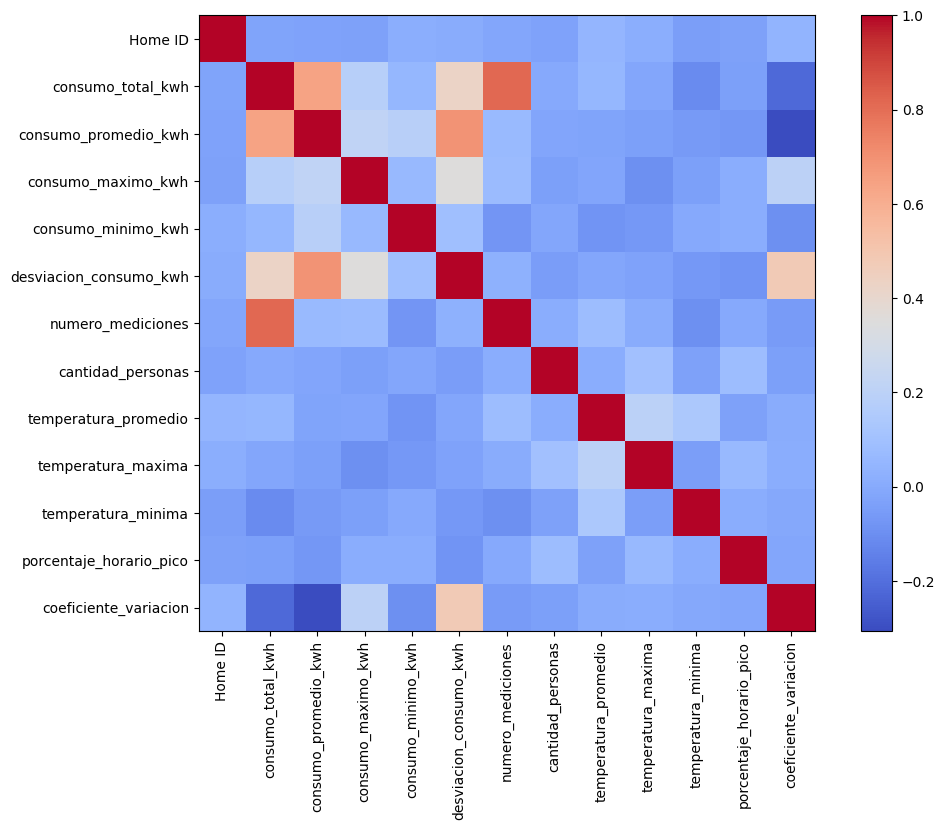

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.show()

In [96]:
homes.isnull().sum()

,0
Home ID,0
consumo_total_kwh,0
consumo_promedio_kwh,0
consumo_maximo_kwh,0
consumo_minimo_kwh,0
desviacion_consumo_kwh,0
numero_mediciones,0
cantidad_personas,0
temperatura_promedio,0
temperatura_maxima,0


# 15. Validaciones finales

Antes de exportar el Dataset Maestro se ejecutan las validaciones finales del
pipeline.

In [97]:
# ==========================================================
# VALIDACIONES FINALES
# ==========================================================

def validate_final_dataset(original_df, final_df):

    assert final_df["Home ID"].is_unique

    assert final_df.isnull().sum().sum() == 0

    assert final_df.duplicated().sum() == 0

    validate_energy(original_df, final_df)

    print("\n✓ Dataset Maestro validado correctamente.")

In [98]:
validate_final_dataset(df, homes)

VALIDACIÓN DE CONSERVACIÓN DE ENERGÍA
Energía original : 149995.1600
Energía agregada : 149995.1600
Diferencia       : 0.0000000000

✓ Conservación de energía verificada.

✓ Dataset Maestro validado correctamente.


# 16. Exportación del Dataset Maestro

Una vez finalizado el proceso de construcción y validación, el Dataset Maestro
se exporta para ser utilizado por el equipo CD3 durante la etapa de entrenamiento
y evaluación de modelos de Machine Learning.

In [99]:
# ==========================================================
# EXPORTACIÓN DEL DATASET MAESTRO
# ==========================================================

from pathlib import Path

# Crear carpeta de salida si no existe
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Ruta del archivo
output_file = output_dir / "dataset_maestro.csv"

# Exportar
homes.to_csv(output_file, index=False)

print("=" * 70)
print("EXPORTACIÓN DEL DATASET")
print("=" * 70)
print(f"Archivo generado: {output_file.resolve()}")
print(f"Número de hogares: {len(homes)}")
print(f"Número de variables: {homes.shape[1]}")
print("\n✓ Dataset Maestro exportado correctamente.")

EXPORTACIÓN DEL DATASET
Archivo generado: /content/output/dataset_maestro.csv
Número de hogares: 500
Número de variables: 13

✓ Dataset Maestro exportado correctamente.


In [100]:
# ==========================================================
# VERIFICACIÓN DE EXPORTACIÓN
# ==========================================================

import pandas as pd

dataset_exportado = pd.read_csv(output_file)

print(dataset_exportado.head())

print("\nDimensiones:", dataset_exportado.shape)

   Home ID  consumo_total_kwh  consumo_promedio_kwh  consumo_maximo_kwh  \
0        1             324.76              1.539147                4.88   
1        2             311.52              1.490526                4.93   
2        3             332.06              1.537315                4.98   
3        4             262.56              1.458667                4.92   
4        5             297.07              1.435121                4.91   

   consumo_minimo_kwh  desviacion_consumo_kwh  numero_mediciones  \
0                0.10                1.171695                211   
1                0.15                1.096428                209   
2                0.14                1.229080                216   
3                0.11                1.153659                180   
4                0.12                1.175420                207   

   cantidad_personas  temperatura_promedio  temperatura_maxima  \
0                  3             13.632701                39.8   
1       

# 17. Construcción del Dataset Oficial para CD3

El Dataset Maestro contiene variables adicionales utilizadas para validación y
auditoría del proceso de ingeniería de características.

Para la integración con el equipo CD3 se genera un dataset simplificado que
conserva únicamente las variables definidas en el documento metodológico.

In [106]:
# ==========================================================
# DATASET OFICIAL PARA CD3 36
# ==========================================================

dataset_cd3 = homes[[
    "Home ID",
    "consumo_total_kwh",
    "cantidad_personas",
    "cantidad_equipos",
    "temperatura_promedio",
    "uso_horario_pico"
]].copy()

# Renombrar columnas según la especificación oficial
dataset_cd3.rename(columns={
    "consumo_total_kwh": "consumo_kwh",
    "temperatura_promedio": "temperatura_exterior"
}, inplace=True)

print("=" * 70)
print("DATASET OFICIAL PARA CD3")
print("=" * 70)

print(f"Registros : {len(dataset_cd3)}")
print(f"Variables : {dataset_cd3.shape[1]}")

dataset_cd3.head()

DATASET OFICIAL PARA CD3
Registros : 500
Variables : 6


,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico
0,1,324.76,3,10,13.632701,False
1,2,311.52,3,10,15.357895,False
2,3,332.06,5,10,13.097685,False
3,4,262.56,5,10,13.543333,False
4,5,297.07,1,10,13.954106,False


# 18. Partición Train/Test

El dataset oficial se divide en conjuntos de entrenamiento y prueba utilizando una
proporción 80/20.

Se utiliza `random_state = 42` para garantizar la reproducibilidad de los
experimentos.

Posteriormente se verifica que ningún hogar (Home ID) esté presente en ambos
conjuntos.

In [107]:
# ==========================================================
# PARTICIÓN TRAIN / TEST 38
# ==========================================================

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    dataset_cd3,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("=" * 70)
print("PARTICIÓN TRAIN / TEST")
print("=" * 70)

print(f"Registros entrenamiento : {len(train_df)}")
print(f"Registros prueba        : {len(test_df)}")

PARTICIÓN TRAIN / TEST
Registros entrenamiento : 400
Registros prueba        : 100


In [108]:
# ==========================================================
# VALIDACIÓN TRAIN / TEST
# ==========================================================

hogares_repetidos = set(train_df["Home ID"]).intersection(
    set(test_df["Home ID"])
)

print("=" * 70)
print("VALIDACIÓN TRAIN / TEST")
print("=" * 70)

print(f"Hogares repetidos: {len(hogares_repetidos)}")

assert len(hogares_repetidos) == 0, \
    "Existen hogares repetidos entre Train y Test."

print("✓ No existen hogares repetidos.")

VALIDACIÓN TRAIN / TEST
Hogares repetidos: 0
✓ No existen hogares repetidos.


# 19. Exportación de los conjuntos de entrenamiento y prueba

Finalmente se exportan los archivos que serán entregados al equipo CD3 para la
construcción y evaluación del modelo de Machine Learning.

In [109]:
# ==========================================================
# EXPORTACIÓN TRAIN / TEST
# ==========================================================

train_file = output_dir / "smart_home_train.csv"
test_file = output_dir / "smart_home_test.csv"

train_df.to_csv(train_file, index=False)
test_df.to_csv(test_file, index=False)

print("=" * 70)
print("ARCHIVOS GENERADOS")
print("=" * 70)

print(f"Train : {train_file.resolve()}")
print(f"Test  : {test_file.resolve()}")

print("\n✓ Exportación completada.")

ARCHIVOS GENERADOS
Train : /content/output/smart_home_train.csv
Test  : /content/output/smart_home_test.csv

✓ Exportación completada.


In [110]:
# ==========================================================
# VERIFICACIÓN DE LOS ARCHIVOS EXPORTADOS
# ==========================================================

train_check = pd.read_csv(train_file)
test_check = pd.read_csv(test_file)

print("Train:", train_check.shape)
print("Test :", test_check.shape)

print("\nColumnas Train")
print(train_check.columns.tolist())

print("\nColumnas Test")
print(test_check.columns.tolist())

Train: (400, 6)
Test : (100, 6)

Columnas Train
['Home ID', 'consumo_kwh', 'cantidad_personas', 'cantidad_equipos', 'temperatura_exterior', 'uso_horario_pico']

Columnas Test
['Home ID', 'consumo_kwh', 'cantidad_personas', 'cantidad_equipos', 'temperatura_exterior', 'uso_horario_pico']
